# Compare saved detector runs
Change `RUNS`, `SELECTION_MODE`, and `POLICY` in the next cell. For real comparisons, point each alias at a different run's `threshold_comparison` directory. Summary sections load exported scores; the final example-inspection section replays saved checkpoints on current validation data at their exported operating points. It does not retrain, resweep thresholds, or retune a model.

Selections and scores below come from the same validation recordings (`tuned_validation`), so these are descriptive comparisons, not independent test-set estimates. The loader rejects incompatible data, preprocessing, threshold grids, matching rules, or selection constraints.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Open from repository root or main_notebooks/'

RUNS = {
    'Baseline': 'testing_checkpoints/baseline(2)/threshold_comparison',
    '(labels delayed 8 frames)': 'testing_checkpoints/baseline_delay_8(2)/threshold_comparison',
    '(baseline, no augmentation)': 'testing_checkpoints/baseline_no_augment/threshold_comparison',
    '(labels delayed 8 frames, no augmentation)': 'testing_checkpoints/delay8_no_augment/threshold_comparison',
}
SELECTION_MODE = 'max_f1'
POLICY = 'lookahead_12f'
assert len(RUNS) >= 2, 'Provide at least two uniquely named runs.'

def read_export(directory, name):
    path = directory / f'{name}.csv'
    if not path.is_file():
        raise FileNotFoundError(f'{path}: rerun the export cell in evaluate.ipynb')
    return pd.read_csv(path)

sources, selections, summaries, type_tables, file_tables = [], [], [], [], []
for label, folder in RUNS.items():
    directory = ROOT / folder
    selected = read_export(directory, 'selected_thresholds')
    chosen = selected[(selected.selection_mode == SELECTION_MODE) & (selected.policy == POLICY)]
    if len(chosen) != 1:
        raise ValueError(f'{label}: expected exactly one selection for {SELECTION_MODE}/{POLICY}')
    choice = chosen.iloc[0]
    if not bool(choice.feasible):
        raise ValueError(f'{label}: requested selection is infeasible: {choice.infeasible_reason}')
    tables = [read_export(directory, name) for name in
              ('comparison_summary', 'type_metrics_all_modes', 'recording_metrics_all_modes')]
    matching = [table[(table.selection_mode == SELECTION_MODE) & (table.policy == POLICY)].copy()
                for table in tables]
    for table in matching:
        assert len(table), f'{label}: selected mode/policy missing in an exported table'
        assert np.allclose(table.left_threshold, choice.left_threshold)
        assert np.allclose(table.right_threshold, choice.right_threshold)
        assert table.checkpoint_sha256.nunique() == 1
        assert table.checkpoint_sha256.iloc[0] == choice.checkpoint_sha256
        table['model'] = label
    summary, by_type, by_file = matching
    assert set(summary.level) == {'window', 'frame', 'event'}
    assert set(summary.side) == {'all', 'left', 'right'}
    assert len(summary) == 9
    for kind in ('window', 'event'):
        overall = summary[(summary.level == kind) & (summary.side == 'all')].iloc[0]
        for count in ('tp', 'fp', 'fn'):
            assert by_file[f'{kind}_{count}'].sum() == by_type[f'{kind}_{count}'].sum() == overall[count]
    sources.append(dict(model=label, folder=str(directory), model_id=choice.model_id,
                        checkpoint_sha256=choice.checkpoint_sha256,
                        validation_sha256=choice.validation_sha256,
                        preprocessing_sha256=choice.preprocessing_sha256,
                        evaluation_design=choice.evaluation_design))
    selections.append(choice.to_dict() | {'model': label})
    summaries.append(summary)
    type_tables.append(by_type)
    file_tables.append(by_file)
comparison_sources = pd.DataFrame(sources)
operating_points = pd.DataFrame(selections)
scores = pd.concat(summaries, ignore_index=True)
type_scores = pd.concat(type_tables, ignore_index=True)
file_scores = pd.concat(file_tables, ignore_index=True)
must_agree = ['validation_sha256', 'preprocessing_sha256', 'selection_split',
              'evaluation_split', 'evaluation_design', 'threshold_grid', 'recall_target',
              'fp_per_min_limit', 'timely_budget_frames', 'early_allowance_frames',
              'max_late_frames', 'refractory_sec', 'frame_label_half_width']
for field in must_agree:
    assert scores[field].nunique(dropna=False) == 1, f'Runs differ in {field}; comparison is not like-for-like'
first_label = next(iter(RUNS))
expected_files = set(file_scores[file_scores.model == first_label].file)
expected_types = set(type_scores[type_scores.model == first_label].recording_type)
for label in RUNS:
    assert set(file_scores[file_scores.model == label].file) == expected_files, 'Recordings differ'
    assert set(type_scores[type_scores.model == label].recording_type) == expected_types, 'Types differ'
if comparison_sources.checkpoint_sha256.nunique() < len(RUNS):
    print('Demo: some aliases use identical weights. Replace RUNS paths to compare different models.')
comparison_sources

,model,folder,model_id,checkpoint_sha256,validation_sha256,preprocessing_sha256,evaluation_design
0,Baseline,/home/aprohack/desktop/work/tap-project/projec...,baseline(2),ee489418feab7db16b82fe84b12dfe31ba6b9c8494d4e0...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
1,(labels delayed 8 frames),/home/aprohack/desktop/work/tap-project/projec...,baseline_delay_8(2),ac81bb8e37ef43c924d83b37fadf6f1dd893a5f7a01569...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
2,"(baseline, no augmentation)",/home/aprohack/desktop/work/tap-project/projec...,baseline_no_augment,94b2d50e4b31a2e7f91a0111a131915d6f3100312d8db7...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
3,"(labels delayed 8 frames, no augmentation)",/home/aprohack/desktop/work/tap-project/projec...,delay8_no_augment,38f41e5682a022d938a26f17dac1a4a543a7a80dca17ef...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation


In [2]:
operating_points[['model', 'selection_mode', 'policy', 'left_threshold', 'right_threshold',
                  'macro_f1', 'left_recall', 'right_recall', 'fp_per_min']]

,model,selection_mode,policy,left_threshold,right_threshold,macro_f1,left_recall,right_recall,fp_per_min
0,Baseline,max_f1,lookahead_12f,0.70,0.65,0.920869,0.923567,0.900585,0.772136
1,(labels delayed 8 frames),max_f1,lookahead_12f,0.70,0.65,0.961772,0.949045,0.953216,0.302140
2,"(baseline, no augmentation)",max_f1,lookahead_12f,0.60,0.60,0.896947,0.904459,0.847953,0.839278
3,"(labels delayed 8 frames, no augmentation)",max_f1,lookahead_12f,0.65,0.60,0.964166,0.987261,0.959064,0.503567


## Window classification
All models use their **selected** left/right thresholds. Bar heights are per-window metrics, not event alarm quality. `class_accuracy` requires the correct side; binary accuracy treats either side as a detected event. PR-AUC is threshold-independent.

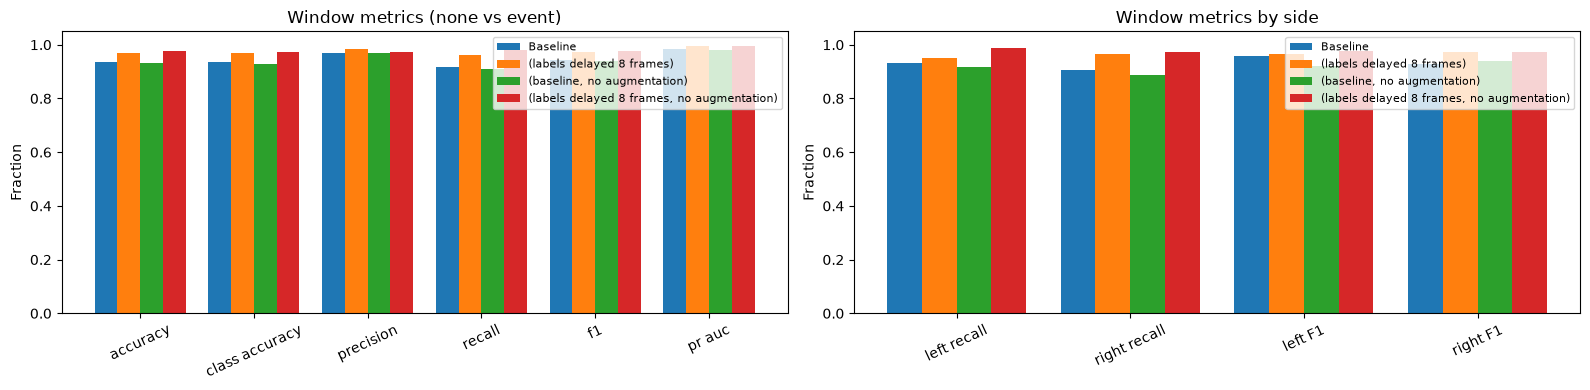

In [3]:
def grouped_bars(ax, table, columns, title, *, scale=1, ylabel='Score'):
    x = np.arange(len(columns))
    width = .8 / len(table)
    for i, (_, row) in enumerate(table.iterrows()):
        values = [row[column] * scale for column in columns]
        ax.bar(x - .4 + width*(i+.5), values, width, label=row['model'])
    ax.set(xticks=x, xticklabels=[name.replace('_', ' ') for name in columns],
           title=title, ylabel=ylabel)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

window_metrics = scores[scores.level == 'window'].copy()
overall = window_metrics[window_metrics.side == 'all']
by_side = window_metrics[window_metrics.side != 'all'].copy()
by_side['side_recall'] = by_side.side + ' recall'
by_side['side_f1'] = by_side.side + ' F1'
per_side = pd.concat([
    by_side.pivot(index='model', columns='side_recall', values='recall'),
    by_side.pivot(index='model', columns='side_f1', values='f1')], axis=1).reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
grouped_bars(axes[0], overall, ['accuracy', 'class_accuracy', 'precision', 'recall', 'f1', 'pr_auc'],
             'Window metrics (none vs event)', ylabel='Fraction')
grouped_bars(axes[1], per_side, [c for c in per_side if c != 'model'],
             'Window metrics by side', ylabel='Fraction')
for ax in axes: ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [4]:
window_metrics[['model', 'side', 'left_threshold', 'right_threshold', 'n_samples',
                'tp', 'fp', 'fn', 'tn', 'accuracy', 'class_accuracy', 'precision',
                'recall', 'f1', 'pr_auc', 'roc_auc']]  # Full table: window_metrics.

,model,side,left_threshold,right_threshold,n_samples,tp,fp,fn,tn,accuracy,class_accuracy,precision,recall,f1,pr_auc,roc_auc
0,Baseline,all,0.70,0.65,598.0,310.0,10.0,28.0,250.0,0.936455,0.936455,0.968750,0.917160,0.942249,0.984289,0.982510
1,Baseline,left,0.70,0.65,598.0,147.0,2.0,11.0,438.0,0.978261,NaN,0.986577,0.930380,0.957655,0.981980,0.994620
2,Baseline,right,0.70,0.65,598.0,163.0,8.0,17.0,410.0,0.958194,NaN,0.953216,0.905556,0.928775,0.982299,0.992650
9,(labels delayed 8 frames),all,0.70,0.65,598.0,325.0,5.0,13.0,255.0,0.969900,0.968227,0.984848,0.961538,0.973054,0.996205,0.995528
10,(labels delayed 8 frames),left,0.70,0.65,598.0,150.0,3.0,8.0,437.0,0.981605,NaN,0.980392,0.949367,0.964630,0.991471,0.996404
11,(labels delayed 8 frames),right,0.70,0.65,598.0,174.0,3.0,6.0,415.0,0.984950,NaN,0.983051,0.966667,0.974790,0.995109,0.997967
18,"(baseline, no augmentation)",all,0.60,0.60,598.0,308.0,10.0,30.0,250.0,0.933110,0.928094,0.968553,0.911243,0.939024,0.980187,0.975444
19,"(baseline, no augmentation)",left,0.60,0.60,598.0,145.0,12.0,13.0,428.0,0.958194,NaN,0.923567,0.917722,0.920635,0.964860,0.989197
20,"(baseline, no augmentation)",right,0.60,0.60,598.0,160.0,1.0,20.0,417.0,0.964883,NaN,0.993789,0.888889,0.938416,0.982852,0.988929
27,"(labels delayed 8 frames, no augmentation)",all,0.65,0.60,598.0,332.0,9.0,6.0,251.0,0.974916,0.973244,0.973607,0.982249,0.977909,0.994783,0.994242


## Frame diagnostics
These per-frame values depend on the selected thresholds, except PR-AUC/ROC-AUC. Frames near the same physical event are correlated; streaming event results below are the primary product metrics.

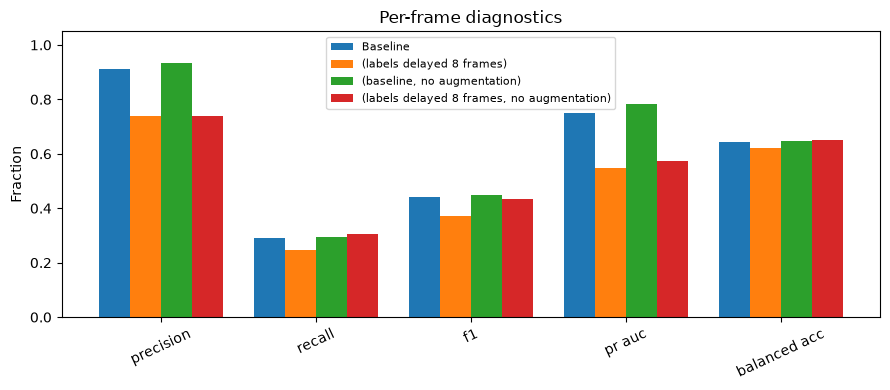

In [5]:
frame_metrics = scores[scores.level == 'frame'].copy()
fig, ax = plt.subplots(figsize=(9, 4))
grouped_bars(ax, frame_metrics[frame_metrics.side == 'all'],
             ['precision', 'recall', 'f1', 'pr_auc', 'balanced_acc'],
             'Per-frame diagnostics', ylabel='Fraction')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [6]:
frame_metrics[['model', 'side', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
               'n_samples', 'tp', 'fp', 'fn']]  # Full table: frame_metrics.

,model,side,precision,recall,f1,pr_auc,roc_auc,n_samples,tp,fp,fn
3,Baseline,all,0.913142,0.291521,0.441950,0.751229,0.972139,178725.0,2008.0,191.0,4880.0
4,Baseline,left,0.930894,0.277828,0.427937,0.735995,0.983257,178725.0,916.0,68.0,2381.0
5,Baseline,right,0.898765,0.304094,0.454432,0.770790,0.977022,178725.0,1092.0,123.0,2499.0
12,(labels delayed 8 frames),all,0.740644,0.247096,0.370564,0.547475,0.954518,178725.0,1702.0,596.0,5186.0
13,(labels delayed 8 frames),left,0.716463,0.213831,0.329362,0.481080,0.962999,178725.0,705.0,279.0,2592.0
14,(labels delayed 8 frames),right,0.758752,0.277639,0.406524,0.603373,0.980935,178725.0,997.0,317.0,2594.0
21,"(baseline, no augmentation)",all,0.934223,0.294861,0.448245,0.781830,0.984240,178725.0,2031.0,143.0,4857.0
22,"(baseline, no augmentation)",left,0.928571,0.315438,0.470908,0.785729,0.991942,178725.0,1040.0,80.0,2257.0
23,"(baseline, no augmentation)",right,0.931689,0.273461,0.422820,0.760522,0.986341,178725.0,982.0,72.0,2609.0
30,"(labels delayed 8 frames, no augmentation)",all,0.738856,0.305604,0.432371,0.573132,0.957400,178725.0,2105.0,744.0,4783.0


## Streaming event detection
Event matching is class-aware, one-to-one, and uses the **actual alarm-emission frame**. FP/min counts unmatched alarms over all validation minutes, including early and wrong-side alarms. The selected operating point can differ per model even though its selection mode is the same.

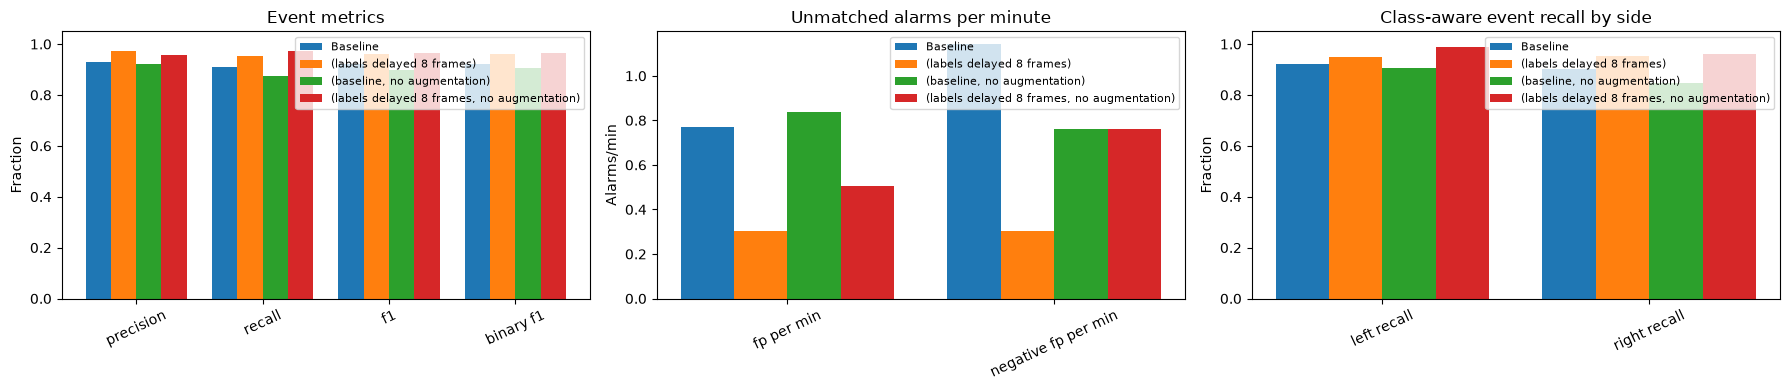

In [7]:
event_metrics = scores[scores.level == 'event'].copy()
event_overall = event_metrics[event_metrics.side == 'all']
event_side = event_metrics[event_metrics.side != 'all'].copy()
event_side['side_recall'] = event_side.side + ' recall'
side_recall = event_side.pivot(index='model', columns='side_recall', values='recall').reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
grouped_bars(axes[0], event_overall, ['precision', 'recall', 'f1', 'binary_f1'],
             'Event metrics', ylabel='Fraction')
grouped_bars(axes[1], event_overall, ['fp_per_min', 'negative_fp_per_min'],
             'Unmatched alarms per minute', ylabel='Alarms/min')
grouped_bars(axes[2], side_recall, [c for c in side_recall if c != 'model'],
             'Class-aware event recall by side', ylabel='Fraction')
axes[0].set_ylim(0, 1.05)
axes[2].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [8]:
event_metrics[['model', 'side', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1',
               'binary_f1', 'fp_per_min', 'negative_fp_per_min',
               'left_threshold', 'right_threshold']]  # Full table: event_metrics.

,model,side,tp,fp,fn,precision,recall,f1,binary_f1,fp_per_min,negative_fp_per_min,left_threshold,right_threshold
6,Baseline,all,299.0,23.0,29.0,0.928571,0.911585,0.920000,0.920000,0.772136,1.142654,0.70,0.65
7,Baseline,left,145.0,7.0,12.0,0.953947,0.923567,0.938511,NaN,0.234998,0.380885,0.70,0.65
8,Baseline,right,154.0,16.0,17.0,0.905882,0.900585,0.903226,NaN,0.537138,0.761769,0.70,0.65
15,(labels delayed 8 frames),all,312.0,9.0,16.0,0.971963,0.951220,0.961479,0.961479,0.302140,0.304708,0.70,0.65
16,(labels delayed 8 frames),left,149.0,2.0,8.0,0.986755,0.949045,0.967532,NaN,0.067142,0.152354,0.70,0.65
17,(labels delayed 8 frames),right,163.0,7.0,8.0,0.958824,0.953216,0.956012,NaN,0.234998,0.152354,0.70,0.65
24,"(baseline, no augmentation)",all,287.0,25.0,41.0,0.919872,0.875000,0.896875,0.906250,0.839278,0.761769,0.60,0.60
25,"(baseline, no augmentation)",left,142.0,16.0,15.0,0.898734,0.904459,0.901587,NaN,0.537138,0.761769,0.60,0.60
26,"(baseline, no augmentation)",right,145.0,9.0,26.0,0.941558,0.847953,0.892308,NaN,0.302140,0.000000,0.60,0.60
33,"(labels delayed 8 frames, no augmentation)",all,319.0,15.0,9.0,0.955090,0.972561,0.963746,0.963746,0.503567,0.761769,0.65,0.60


## Alarm latency
Deadline recall is the fraction of **all annotated events** detected before X frames (misses remain in the denominator). Mean/median/p90 latency includes matched events only and can be misleading if recall is low.

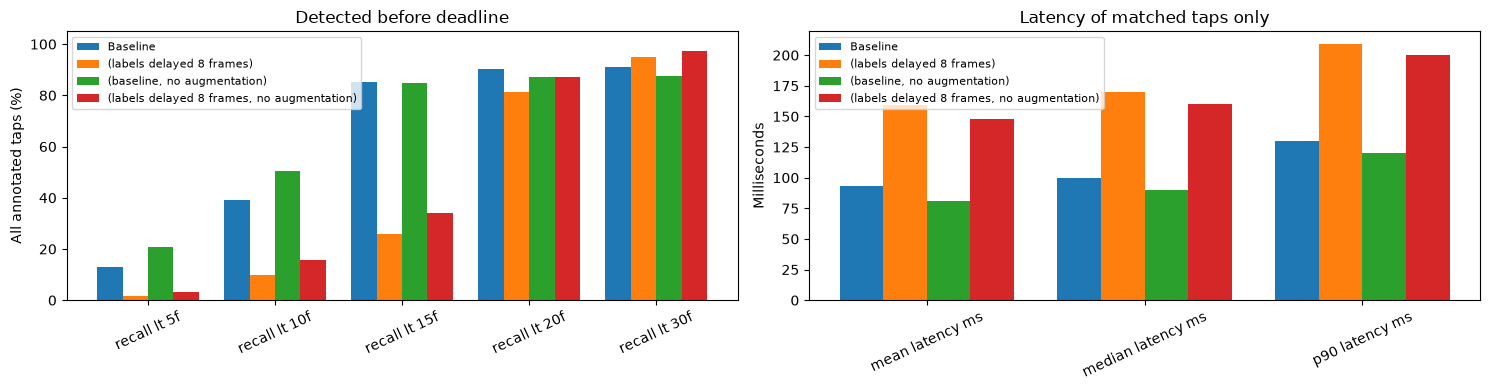

In [9]:
latency_metrics = event_overall[['model', 'left_threshold', 'right_threshold',
                                 'recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f',
                                 'recall_lt_20f', 'recall_lt_30f', 'mean_latency_ms',
                                 'median_latency_ms', 'p90_latency_ms', 'tp', 'fn']].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
grouped_bars(axes[0], latency_metrics,
             ['recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f', 'recall_lt_20f', 'recall_lt_30f'],
             'Detected before deadline', scale=100, ylabel='All annotated taps (%)')
grouped_bars(axes[1], latency_metrics,
             ['mean_latency_ms', 'median_latency_ms', 'p90_latency_ms'],
             'Latency of matched taps only', ylabel='Milliseconds')
axes[0].set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [10]:
latency_metrics  # Filter model and compare recall/latency at the same deadline.

,model,left_threshold,right_threshold,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f,mean_latency_ms,median_latency_ms,p90_latency_ms,tp,fn
6,Baseline,0.70,0.65,0.128049,0.390244,0.850610,0.902439,0.911585,93.545151,100.0,130.0,299.0,29.0
15,(labels delayed 8 frames),0.70,0.65,0.015244,0.097561,0.259146,0.814024,0.948171,159.070513,170.0,209.0,312.0,16.0
24,"(baseline, no augmentation)",0.60,0.60,0.207317,0.503049,0.847561,0.871951,0.875000,80.905923,90.0,120.0,287.0,41.0
33,"(labels delayed 8 frames, no augmentation)",0.65,0.60,0.033537,0.158537,0.341463,0.871951,0.972561,147.868339,160.0,200.0,319.0,9.0


## Recording types and individual files
Rows use the same selected policy and left/right thresholds as the event and window plots. Negative-only types have undefined event recall; their FP/min and false-positive window rates are the useful metrics. Grouped by type, every value is pooled over its files (not an average of file percentages). Some types contain only one file.

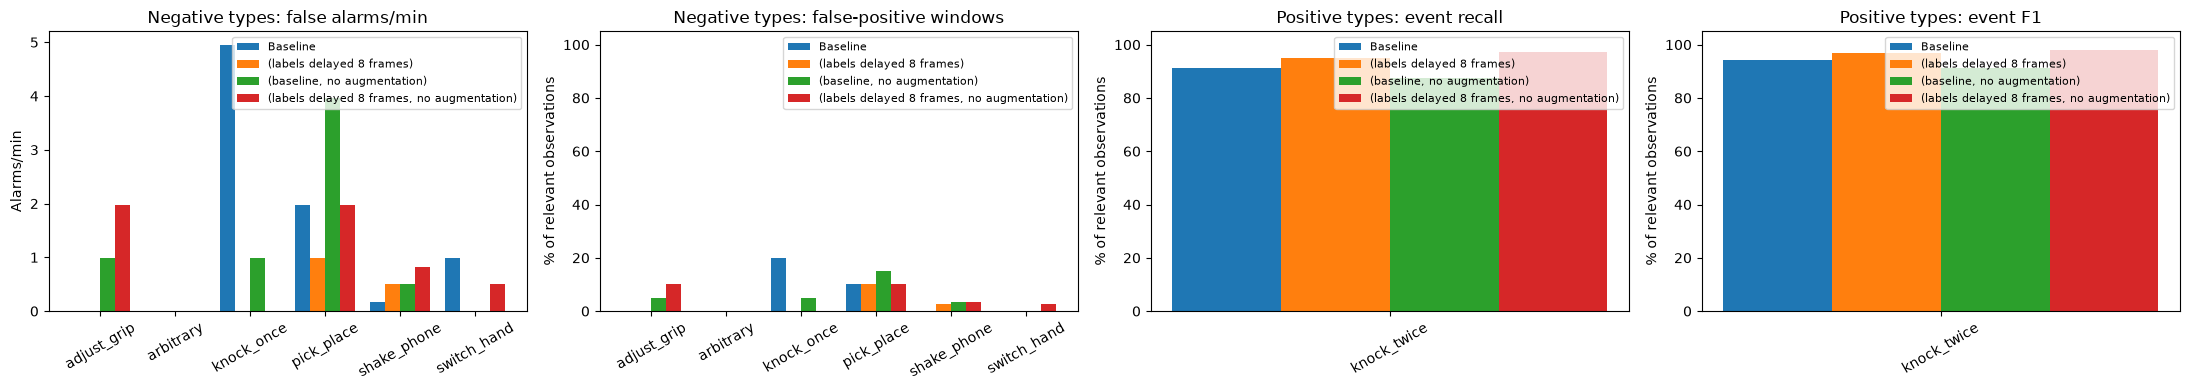

In [11]:
type_comparison = type_scores.copy()
negative = type_comparison[type_comparison.n_true_events == 0]
positive = type_comparison[type_comparison.n_true_events > 0]
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, subset, metric, title, scale in [
        (axes[0], negative, 'event_fp_per_min', 'Negative types: false alarms/min', 1),
        (axes[1], negative, 'window_false_positive_rate', 'Negative types: false-positive windows', 100),
        (axes[2], positive, 'event_recall', 'Positive types: event recall', 100),
        (axes[3], positive, 'event_f1', 'Positive types: event F1', 100)]:
    x = sorted(subset.recording_type.unique())
    width = .8 / len(RUNS)
    for i, label in enumerate(RUNS):
        rows = subset[subset.model == label].set_index('recording_type').reindex(x)
        ax.bar(np.arange(len(x)) - .4 + width*(i+.5), rows[metric] * scale, width, label=label)
    ax.set(xticks=np.arange(len(x)), xticklabels=x, title=title)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Alarms/min')
for ax in axes[1:]: ax.set(ylabel='% of relevant observations', ylim=(0, 105))
plt.tight_layout()
plt.show()

In [12]:
type_comparison[['model', 'recording_type', 'recordings', 'n_windows', 'n_true_events',
                 'event_tp', 'event_fp', 'event_fn', 'event_f1', 'event_fp_per_min',
                 'event_left_recall', 'event_right_recall', 'window_accuracy',
                 'window_false_positive_rate']]  # Full table: type_comparison.

,model,recording_type,recordings,n_windows,n_true_events,event_tp,event_fp,event_fn,event_f1,event_fp_per_min,event_left_recall,event_right_recall,window_accuracy,window_false_positive_rate
0,Baseline,adjust_grip,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
1,Baseline,arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
2,Baseline,knock_once,2,40,0,0,10,0,0.000000,4.955401,NaN,NaN,0.800000,0.200000
3,Baseline,knock_twice,17,338,328,299,8,29,0.941732,0.480187,0.923567,0.900585,0.917160,NaN
4,Baseline,pick_place,1,20,0,0,2,0,0.000000,1.979545,NaN,NaN,0.900000,0.100000
5,Baseline,shake_phone,6,120,0,0,1,0,0.000000,0.165057,NaN,NaN,1.000000,0.000000
6,Baseline,switch_hand,2,40,0,0,2,0,0.000000,0.990099,NaN,NaN,1.000000,0.000000
7,(labels delayed 8 frames),adjust_grip,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
8,(labels delayed 8 frames),arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
9,(labels delayed 8 frames),knock_once,2,40,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000


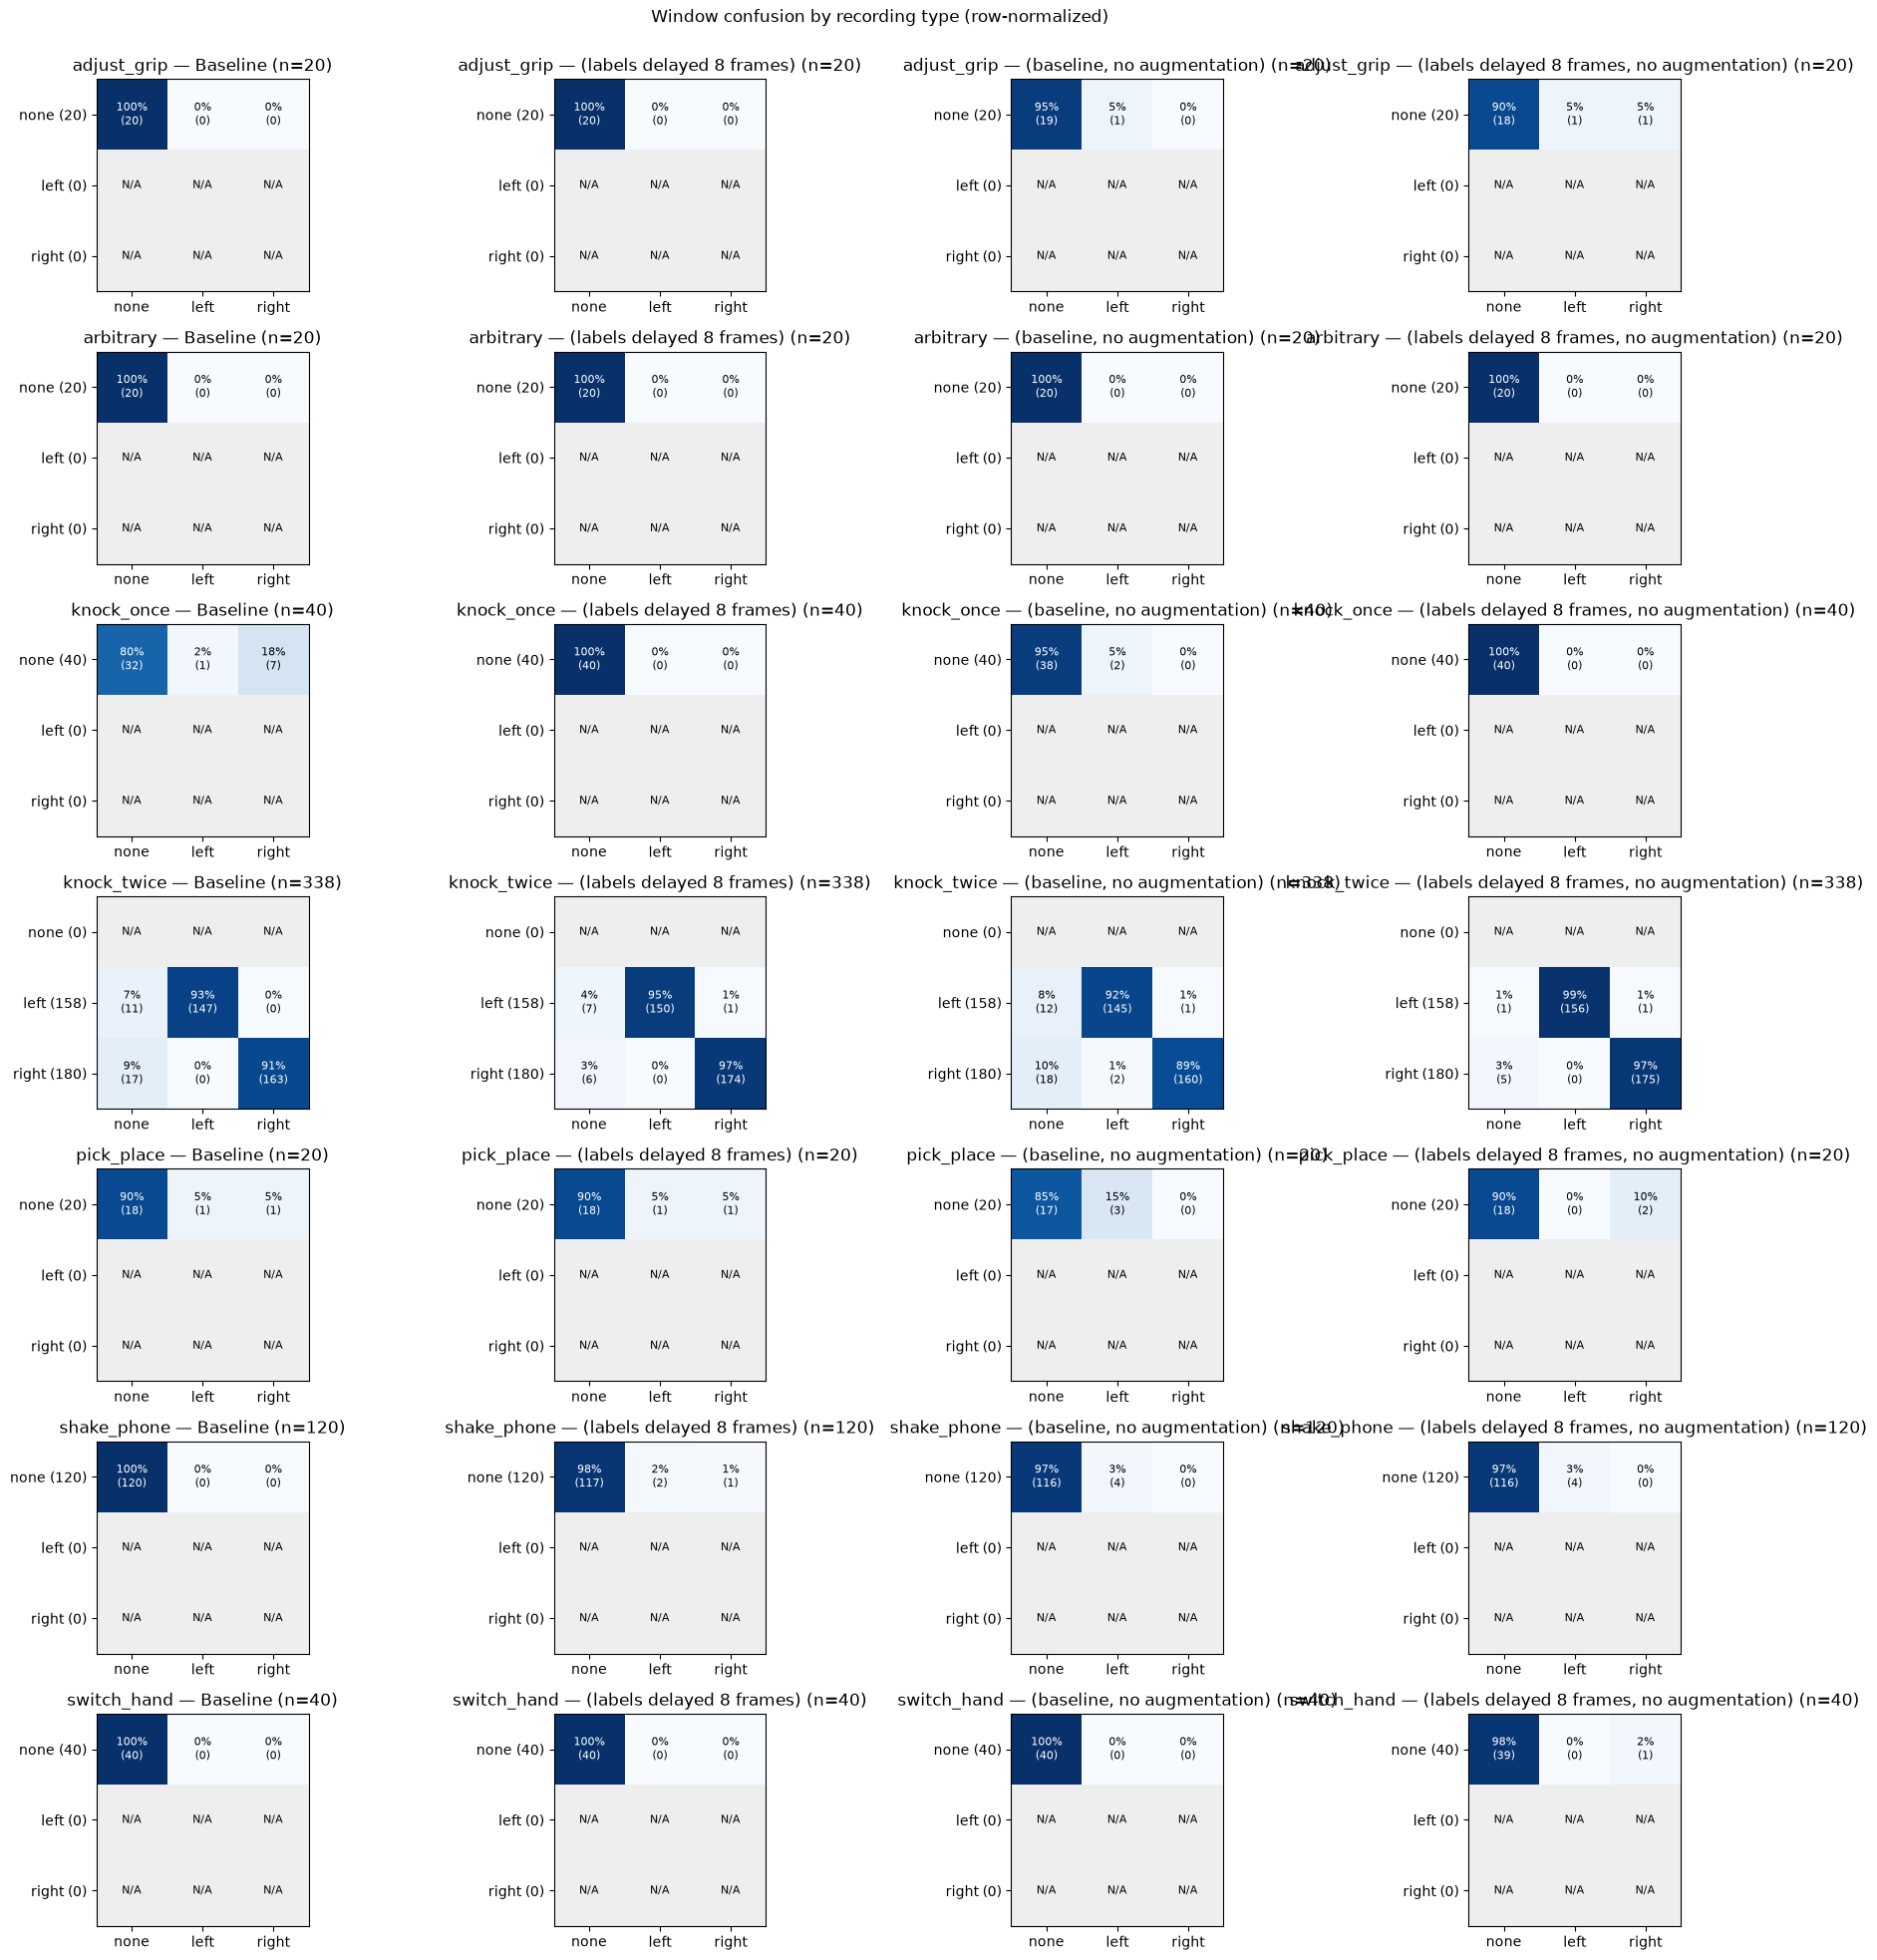

In [13]:
from matplotlib.colors import Normalize
confusion_rows = []
recording_types = sorted(expected_types)
fig, axes = plt.subplots(len(recording_types), len(RUNS),
                         figsize=(4.8*len(RUNS), 2.8*len(recording_types)), squeeze=False)
colors = plt.get_cmap('Blues').copy()
colors.set_bad('#eeeeee')
for i, recording_type in enumerate(recording_types):
    for j, model_name in enumerate(RUNS):
        row = type_comparison[(type_comparison.recording_type == recording_type) &
                              (type_comparison.model == model_name)].iloc[0]
        cm = np.array([[int(row[f'cm_{t}{p}']) for p in range(3)] for t in range(3)])
        totals = cm.sum(axis=1)
        fractions = np.divide(cm, totals[:, None], out=np.full((3, 3), np.nan),
                              where=totals[:, None] > 0)
        ax = axes[i, j]
        ax.imshow(np.ma.masked_invalid(fractions), cmap=colors, norm=Normalize(0, 1))
        ax.set(title=f'{recording_type} — {model_name} (n={cm.sum()})',
               xticks=range(3), xticklabels=('none', 'left', 'right'),
               yticks=range(3), yticklabels=[f'{name} ({n})' for name, n in
                                        zip(('none', 'left', 'right'), totals)])
        for t, true_class in enumerate(('none', 'left', 'right')):
            for p, predicted_class in enumerate(('none', 'left', 'right')):
                ax.text(p, t, f'{fractions[t, p]:.0%}\n({cm[t, p]})' if totals[t] else 'N/A',
                        ha='center', va='center', fontsize=8,
                        color='white' if totals[t] and fractions[t, p] > .55 else 'black')
                confusion_rows.append(dict(model=model_name, recording_type=recording_type,
                                           true_class=true_class, predicted_class=predicted_class,
                                           count=int(cm[t, p]), true_count=int(totals[t]),
                                           row_fraction=fractions[t, p]))
fig.suptitle('Window confusion by recording type (row-normalized)', y=1.001)
plt.tight_layout()
plt.show()
type_confusion_comparison = pd.DataFrame(confusion_rows)

In [14]:
type_confusion_comparison  # N/A rows have no observed examples of that true class.

,model,recording_type,true_class,predicted_class,count,true_count,row_fraction
0,Baseline,adjust_grip,none,none,20,20,1.0
1,Baseline,adjust_grip,none,left,0,20,0.0
2,Baseline,adjust_grip,none,right,0,20,0.0
3,Baseline,adjust_grip,left,none,0,0,NaN
4,Baseline,adjust_grip,left,left,0,0,NaN
...,...,...,...,...,...,...,...
247,"(labels delayed 8 frames, no augmentation)",switch_hand,left,left,0,0,NaN
248,"(labels delayed 8 frames, no augmentation)",switch_hand,left,right,0,0,NaN
249,"(labels delayed 8 frames, no augmentation)",switch_hand,right,none,0,0,NaN
250,"(labels delayed 8 frames, no augmentation)",switch_hand,right,left,0,0,NaN


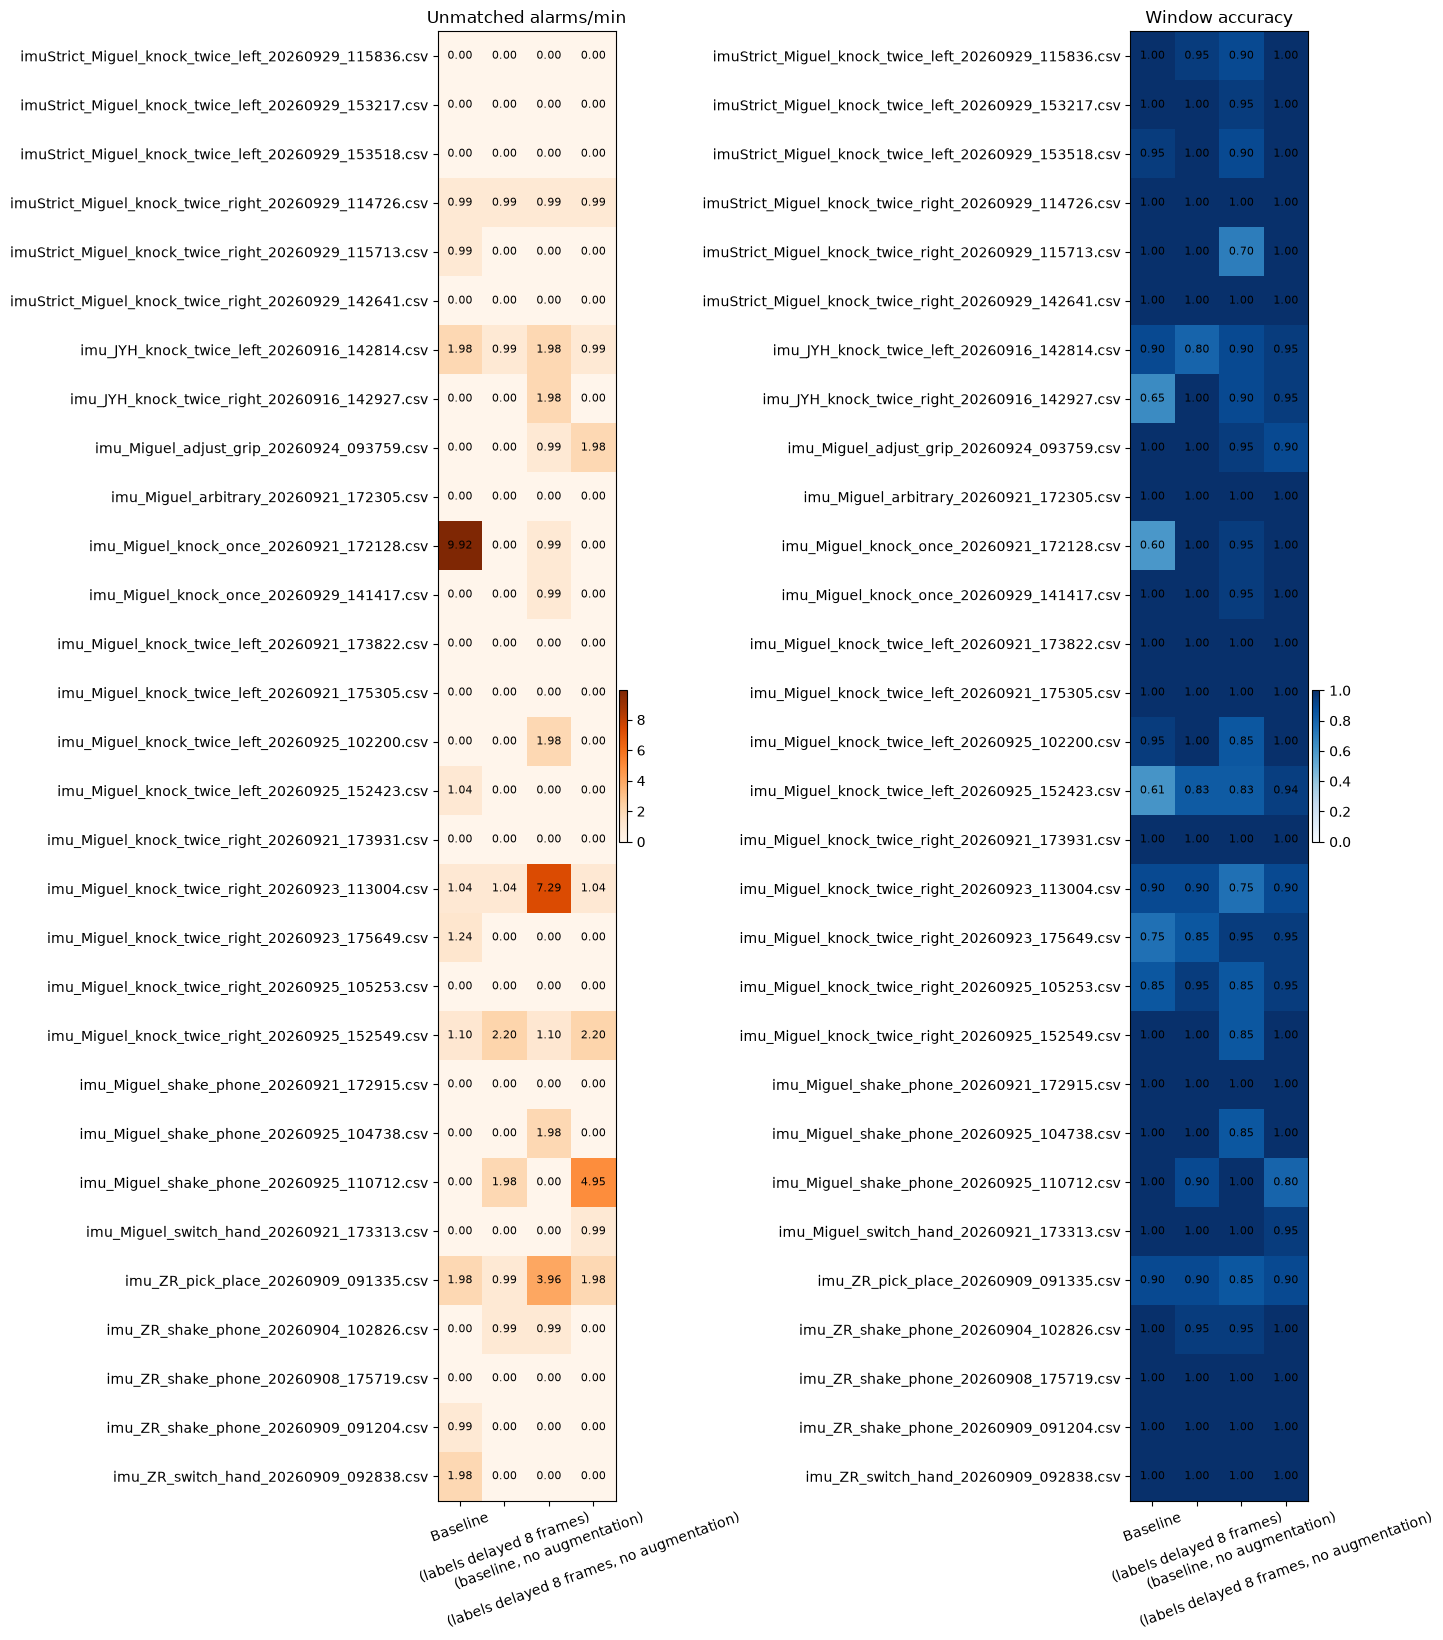

In [15]:
recording_comparison = file_scores.copy()
files = sorted(recording_comparison.file.unique())
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, .55*len(files))))
for ax, field, label, cmap in [
        (axes[0], 'event_fp_per_min', 'Unmatched alarms/min', 'Oranges'),
        (axes[1], 'window_accuracy', 'Window accuracy', 'Blues')]:
    table = recording_comparison.pivot(index='file', columns='model', values=field).reindex(
        index=files, columns=list(RUNS))
    data = table.to_numpy(dtype=float)
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=0, vmax=1 if field == 'window_accuracy' else None)
    ax.set(yticks=np.arange(len(files)), yticklabels=files, xticks=np.arange(len(RUNS)),
           xticklabels=list(RUNS), title=label)
    ax.tick_params(axis='x', rotation=20)
    for i in range(len(files)):
        for j in range(len(RUNS)):
            ax.text(j, i, f'{data[i, j]:.2f}',
                    ha='center', va='center', color='black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=.04, pad=.02)
plt.tight_layout()
plt.show()

In [16]:
recording_comparison[['model', 'file', 'recording_type', 'n_windows',
                      'n_true_events', 'event_tp', 'event_fp', 'event_fn',
                      'window_fp', 'window_fn', 'event_fp_per_min', 'minutes']]  # Full table: recording_comparison.

,model,file,recording_type,n_windows,n_true_events,event_tp,event_fp,event_fn,window_fp,window_fn,event_fp_per_min,minutes
0,Baseline,imuStrict_Miguel_knock_twice_left_20260929_115...,knock_twice,20,20,20,0,0,0,0,0.000000,1.010500
1,Baseline,imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,20,0,0,0,0,0.000000,1.010167
2,Baseline,imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,19,0,1,0,1,0.000000,1.010667
3,Baseline,imuStrict_Miguel_knock_twice_right_20260929_11...,knock_twice,20,20,19,1,1,0,0,0.990262,1.009833
4,Baseline,imuStrict_Miguel_knock_twice_right_20260929_11...,knock_twice,20,20,19,1,1,0,0,0.989772,1.010333
...,...,...,...,...,...,...,...,...,...,...,...,...
115,"(labels delayed 8 frames, no augmentation)",imu_ZR_pick_place_20260909_091335.csv,pick_place,20,0,0,2,0,2,0,1.979545,1.010333
116,"(labels delayed 8 frames, no augmentation)",imu_ZR_shake_phone_20260904_102826.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.008833
117,"(labels delayed 8 frames, no augmentation)",imu_ZR_shake_phone_20260908_175719.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.009000
118,"(labels delayed 8 frames, no augmentation)",imu_ZR_shake_phone_20260909_091204.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.010667


## Inspect individual validation examples (current recordings)
The saved exports above contain per-recording totals, but not individual segment predictions or probability traces. The next cell replays each selected `best.pt` on **the current validation files** at its saved left/right thresholds, with the same window fitting, continuous causal inference, class-aware event matching, and alarm policy as the evaluator. It does not tune thresholds. `example_data_status` shows whether today's raw CSVs, label text files, and exclusion registry still match the original exports. If not, the detailed tables below describe *current-data replay* and must not be mixed with the historical exported totals above.

`segment_scores` and `recording_scores` are long-form filterable tables; `segment_matrix` and `recording_matrix` put each model in its own column group. Segment IDs are the CSV's `segment_index` (not window row numbers). Event TP/FP/FN use one-to-one matching on the **whole recording** before attribution to a segment; `too_early_fp` counts unmatched alarms emitted too early for their nearest tap, while `wrong_side_fp` is an unmatched alarm that matched in the side-agnostic check. Window classification is separate from alarm matching. Excluded segments and unlabeled windows are not scored.


In [17]:
import sys
sys.path.insert(0, str(ROOT))
import torch
from notebooks_analysis.model_comparison_examples import (
    comparison_matrix, plot_example, replay_examples,
)

torch.set_num_threads(2)
detail_points = operating_points.merge(comparison_sources[['model', 'folder']],
                                       on='model', validate='one_to_one')
example_recordings, example_traces, segment_scores, recording_scores, alarm_details, example_data_status = (
    replay_examples(ROOT, detail_points)
)
display(example_data_status)
print('Detailed replay:', len(segment_scores), 'model/segment rows,',
      len(recording_scores), 'model/recording rows,', len(alarm_details), 'alarms')

  Excluding session(s) [3] from imu_Miguel_knock_twice_left_20260925_152423.csv
  Excluding session(s) [18] from imu_Miguel_knock_twice_right_20260923_113004.csv
  Excluding session(s) [4, 8, 12, 19] from imu_Miguel_knock_twice_right_20260923_175649.csv
  Excluding session(s) [18, 20] from imu_Miguel_knock_twice_right_20260925_105253.csv
  Excluding session(s) [10, 17] from imu_Miguel_knock_twice_right_20260925_152549.csv


,model,export_validation_sha256,current_validation_sha256,matches_export
0,Baseline,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False
1,(labels delayed 8 frames),432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False
2,"(baseline, no augmentation)",432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False
3,"(labels delayed 8 frames, no augmentation)",432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False


Detailed replay: 2360 model/segment rows, 120 model/recording rows, 1289 alarms


### Find difficult segments and recordings
Filter `segment_scores.query("recording_type == 'knock_twice' and event_fn > 0")` for missed double taps or `segment_scores.query('too_early_fp > 0 or wrong_side_fp > 0')` for premature/wrong-side alarms. `alarm_details` gives each alarm's global emission/peak frame, closest annotation, matched status, and segment ID. `recording_scores` includes both knock-twice recordings and negative-only activity; its `event_fp_per_min` uses the sum of **included** segment durations. Edit the displayed slices or filter `segment_matrix.loc[('filename.csv', 8)]` / `recording_matrix.loc['filename.csv']` to see every model together.


In [ ]:
segment_matrix = comparison_matrix(segment_scores, ['file', 'segment_index'],
    ['window_true', 'window_pred', 'window_correct', 'window_fp', 'window_fn',
     'p_left_max', 'p_right_max', 'event_tp', 'event_fp', 'event_fn',
     'too_early_fp', 'wrong_side_fp', 'latency_frames'])
recording_matrix = comparison_matrix(recording_scores, ['file'],
    ['recording_type', 'minutes', 'n_windows', 'window_accuracy', 'window_fp', 'window_fn',
     'n_true_events', 'event_tp', 'event_fp', 'event_fn', 'too_early_fp',
     'wrong_side_fp', 'event_fp_per_min'])
segment_difficulty = segment_scores.groupby(['file', 'segment_index', 'recording_type'],
    as_index=False).agg(models_missing=('event_fn', lambda x: (x > 0).sum()),
                        models_false_alarm=('event_fp', lambda x: (x > 0).sum()),
                        models_window_wrong=('window_correct', lambda x: (x == False).sum()),
                        too_early_fp=('too_early_fp', 'sum'), wrong_side_fp=('wrong_side_fp', 'sum'))
print('Hard double-tap segments (one row per CSV segment):')
with pd.option_context('display.max_colwidth', None):
    display(segment_difficulty.query("recording_type == 'knock_twice'")
            .sort_values(['models_missing', 'too_early_fp', 'models_false_alarm'],
                        ascending=False).head(25))
print('Hard recordings (one row per model/recording):')
with pd.option_context('display.max_colwidth', None):
display(recording_scores.sort_values(['event_fp_per_min', 'event_fn'], ascending=False)
        [['model', 'file', 'recording_type', 'n_true_events', 'event_tp', 'event_fp',
          'event_fn', 'too_early_fp', 'window_fp', 'event_fp_per_min']].head(25))

NameError: name 'comparison_matrix' is not defined

### Aligned recording/segment inspection
Choose a `file` and optionally a `segment_index` from the tables. The top row shows acceleration deviation and gyro magnitude from the original CSV; the following rows show each model's left/right probabilities, dotted operating thresholds, annotated second taps (dashed), and emitted alarms (triangles; red edges are unmatched alarms). All rows share the original recording's time axis. Use `REVIEW_SEGMENT = None` to inspect an entire recording.


,model,file,segment_index,window_true,window_pred,event_tp,event_fp,event_fn,too_early_fp,latency_frames


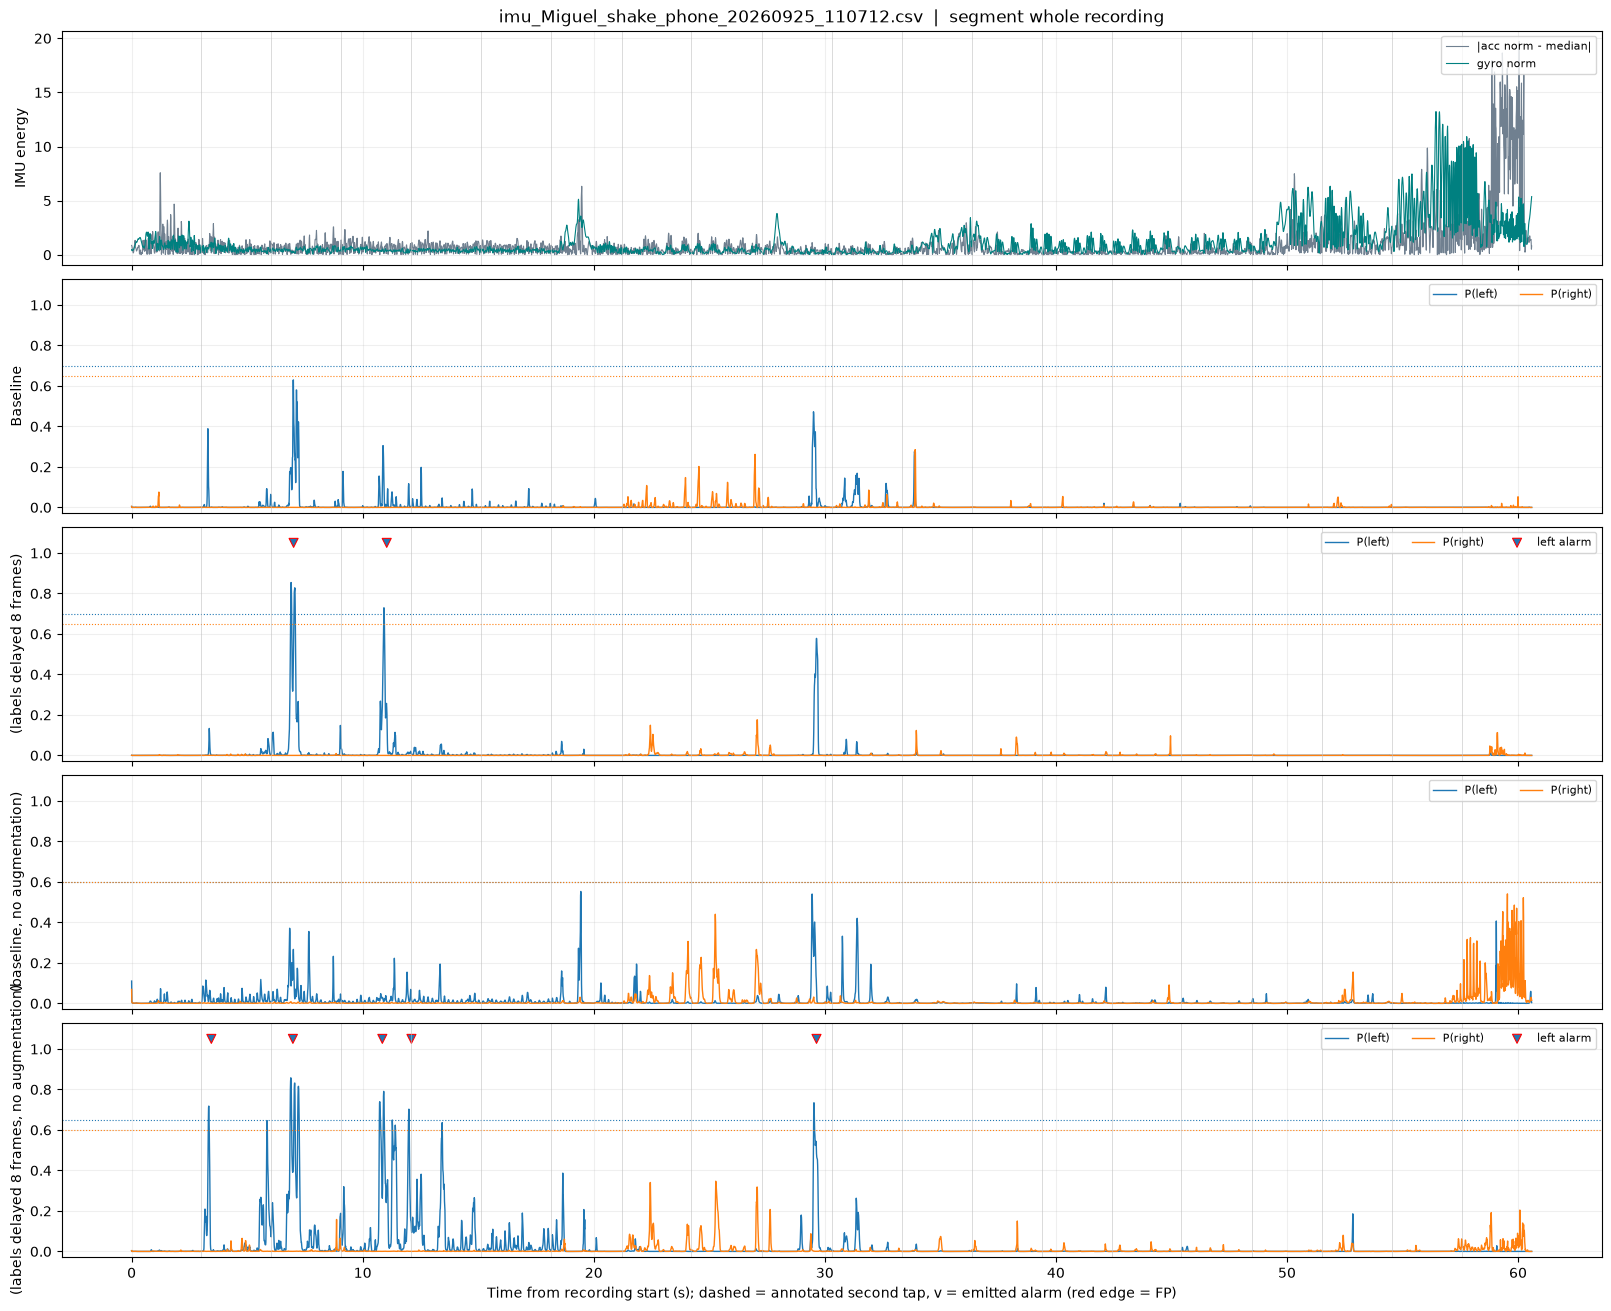

In [19]:
# Replace these values with a file and segment_index from segment_difficulty.
hardest = segment_difficulty.query("recording_type == 'knock_twice'").sort_values(
    ['models_missing', 'too_early_fp', 'models_false_alarm'], ascending=False).iloc[0]
# REVIEW_FILE = hardest['file']
# REVIEW_SEGMENT = int(hardest['segment_index'])  # None = whole recording
REVIEW_FILE = 'imu_Miguel_shake_phone_20260925_110712.csv'
REVIEW_SEGMENT = None
display(segment_scores.query('file == @REVIEW_FILE and segment_index == @REVIEW_SEGMENT')
        [['model', 'file', 'segment_index', 'window_true', 'window_pred',
          'event_tp', 'event_fp', 'event_fn', 'too_early_fp', 'latency_frames']])
fig, axes = plot_example(example_recordings, example_traces, alarm_details,
                         detail_points, REVIEW_FILE, REVIEW_SEGMENT)
plt.show()